Nessa versão foi alterado apenas os parâmetros solver e activation do dicionário MLP_PARAMS

In [45]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)


In [46]:
# ============================================================
# 1. PARÂMETROS DO MLP
# ============================================================

MLP_PARAMS = {
    # Arquitetura da rede
    "hidden_layer_sizes": (64, 32, 16),

    # Função de ativação dos neurônios
    "activation": "tanh",

    # Algoritmo de otimização
    "solver": "sgd",

    # Taxa de aprendizado inicial
    "learning_rate_init": 0.001,

    # Quantidade máxima de épocas
    "max_iter": 100,

    # Tamanho do lote utilizado no treinamento
    "batch_size": 64,

    # Regularização L2
    "alpha": 0.0001,

    # Para interromper quando não houver melhoria
    "early_stopping": True,

    # Parte do treinamento utilizada para validação
    "validation_fraction": 0.1,

    # Número de épocas sem melhoria antes de parar
    "n_iter_no_change": 10,

    # Reprodutibilidade
    "random_state": 42
}

THRESHOLD = 0.90

In [47]:
# ============================================================
# 2. CARREGAMENTO DO DATASET
# ============================================================

arquivo = "C:/Users/gques/Documents/SPTECH_CODIGOS/ultimo-ano/tcc/backend/tabela_final/part-00000-13fcc452-2493-4299-ab17-d369f64d2ad3-c000.csv"


df = pd.read_csv(arquivo)

In [48]:
# ============================================================
# 3. VARIÁVEL TARGET
# ============================================================

target = "delivered_on_time"

# ============================================================
# 4. SPLIT TEMPORAL
# ============================================================

split_date = pd.to_datetime("2018-07-01", utc=True)

date_col = pd.to_datetime(
    df["order_delivered_carrier_date"],
    utc=True
)

train_mask = date_col < split_date
test_mask = date_col >= split_date

df_train = df[train_mask].copy()
df_test = df[test_mask].copy()

print(f"Treino: {len(df_train):,} linhas")
print(f"Teste: {len(df_test):,} linhas")

# ============================================================
# 5. REMOÇÃO DE COLUNAS COM POSSÍVEL DATA LEAKAGE
# ============================================================

colunas_remover = [
    target,
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "interval_code_delivered_carrier",
    "order_delivered_customer_date",
    "interval_code_delivered_customer",
    "order_estimated_delivery_date",
    "shipping_limit_date",
    "is_holiday_in_7_days",
    "is_holiday_in_14_days",
    "had_holiday_7_days_ago",
    "had_holiday_14_days_ago",
    "customer_city",
    "seller_city",
    "delivered_on_time", 
    "category_name",
    "review_score",
    "delivery_time_days"
]

colunas_remover = [
    coluna for coluna in colunas_remover
    if coluna in df.columns
]

Treino: 28,706 linhas
Teste: 5,114 linhas


In [49]:
# ============================================================
# 6. SEPARAÇÃO ENTRE X E Y
# ============================================================

X_train = df_train.drop(columns=colunas_remover)
y_train = df_train[target]

X_test = df_test.drop(columns=colunas_remover)
y_test = df_test[target]


# ============================================================
# 7. CONVERSÃO DE VARIÁVEIS CATEGÓRICAS
# ============================================================

X_train = pd.get_dummies(
    X_train,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    drop_first=True
)

X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

In [50]:
# ============================================================
# 8. TRATAMENTO DE VALORES AUSENTES
# ============================================================

X_train = X_train.replace(
    [np.inf, -np.inf],
    np.nan
)

X_test = X_test.replace(
    [np.inf, -np.inf],
    np.nan
)

X_train = X_train.fillna(
    X_train.median(numeric_only=True)
)

X_test = X_test.fillna(
    X_train.median(numeric_only=True)
)

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [51]:
# ============================================================
# 9. NORMALIZAÇÃO
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


Modelo salvo em: C:/Users/gques/Documents/SPTECH_CODIGOS/ultimo-ano/tcc/backend/modelo/dl/mlp_model_v3.pkl


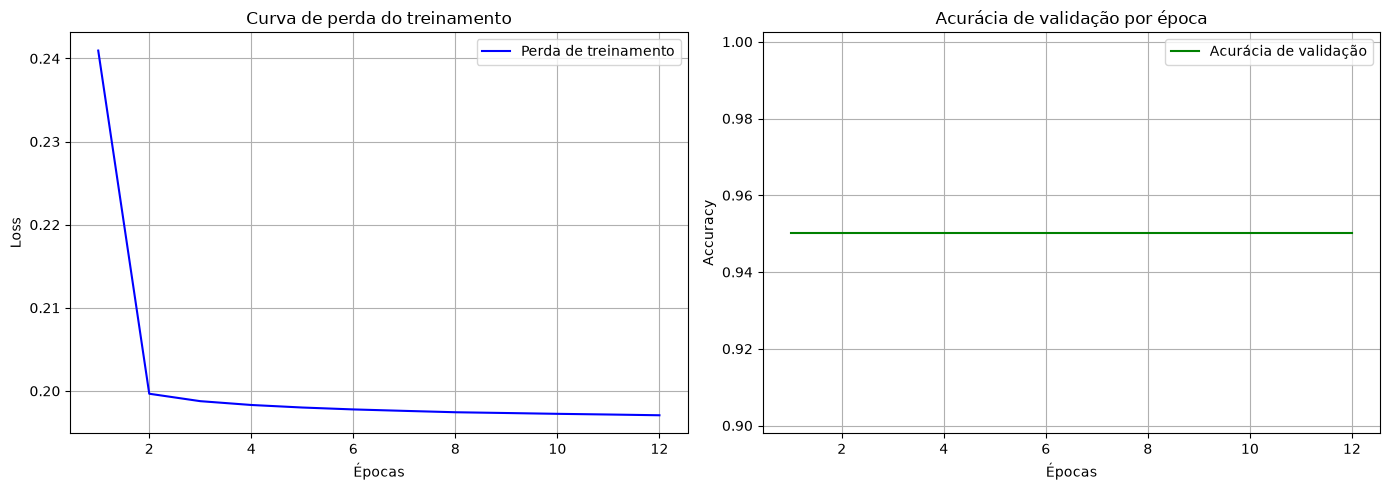

In [52]:
# ============================================================
# 10. CRIAÇÃO DO MLP
# ============================================================

mlp = MLPClassifier(
    **MLP_PARAMS
)


# ============================================================
# 11. TREINAMENTO
# ============================================================

mlp.fit(
    X_train_scaled,
    y_train
)

# ============================================================
# 11.1 SALVAMENTO DO MODELO
# ============================================================

modelo = {
    "model": mlp,
    "scaler": scaler,
    "features": X_train.columns.tolist(),
    "threshold": THRESHOLD
}

caminho_modelo = "C:/Users/gques/Documents/SPTECH_CODIGOS/ultimo-ano/tcc/backend/modelo/dl/mlp_model_v3.pkl"

with open(caminho_modelo, "wb") as arquivo:
    pickle.dump(modelo, arquivo)

print(f"\nModelo salvo em: {caminho_modelo}")


# ============================================================
# 11.2 GRÁFICOS DE TREINAMENTO E VALIDAÇÃO
# ============================================================

epocas = range(1, len(mlp.loss_curve_) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 - Perda do treinamento
axes[0].plot(
    epocas,
    mlp.loss_curve_,
    label="Perda de treinamento",
    color="blue"
)

axes[0].set_title("Curva de perda do treinamento")
axes[0].set_xlabel("Épocas")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[0].legend()

# Gráfico 2 - Acurácia de validação
if mlp.validation_scores_ is not None:
    epocas_validacao = range(
        1,
        len(mlp.validation_scores_) + 1
    )

    axes[1].plot(
        epocas_validacao,
        mlp.validation_scores_,
        label="Acurácia de validação",
        color="green"
    )

    axes[1].set_title("Acurácia de validação por época")
    axes[1].set_xlabel("Épocas")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(True)
    axes[1].legend()

plt.tight_layout()
plt.show()

# Gráfico 01
A curva de perda mostra o erro que o modelo apresenta durante o treinamento.

Curva decrescente: o modelo está aprendendo a ajustar seus pesos.

Curva estabilizada: o treinamento pode ter atingido um platô.

Curva crescente: pode indicar instabilidade ou dificuldades de otimização.

# Gráfico 02

A curva de validação mostra como o modelo classifica as amostras reservadas para validação durante o treinamento.

Acurácia crescente: o modelo está melhorando sua capacidade de classificação no conjunto de validação.

Acurácia estabilizada: pode indicar que o modelo deixou de apresentar melhorias.

Acurácia decrescente: pode indicar que o modelo está perdendo capacidade de generalização.

In [53]:
# ============================================================
# 12. PREDIÇÃO
# ============================================================

#VALORES DE PREDIÇÃO UTILIZADOS NO V1
# y_pred = mlp.predict(
#     X_test_scaled
# )

# y_prob = mlp.predict_proba(
#     X_test_scaled
# )[:, 1]

y_prob = mlp.predict_proba(
    X_test_scaled
)[:, 1]

y_pred = (y_prob >= THRESHOLD).astype(int)

In [54]:
# ============================================================
# 13. MÉTRICAS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    pos_label=0,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label=0,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label=0,
    zero_division=0
)

f2 = fbeta_score(
    y_test,
    y_pred,
    beta=2,
    pos_label=0,
    zero_division=0
)

auc = roc_auc_score(
    y_test,
    y_prob
)

In [55]:
# ============================================================
# 14. RESULTADOS
# ============================================================

print("\n" + "=" * 60)
print("RESULTADOS - MLP")
print("=" * 60)

print(f"Arquitetura: {MLP_PARAMS['hidden_layer_sizes']}")
print(f"Activation: {MLP_PARAMS['activation']}")
print(f"Learning rate: {MLP_PARAMS['learning_rate_init']}")
print(f"Batch size: {MLP_PARAMS['batch_size']}")
print(f"Épocas máximas: {MLP_PARAMS['max_iter']}")

print("\nQuantidade de amostras:")
print(f"Treino: {len(X_train)}")
print(f"Teste:  {len(X_test)}")

print("\nMétricas:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"F2-score:  {f2:.4f}")
print(f"ROC-AUC:   {auc:.4f}")

print("\nMatriz de confusão:")
print(confusion_matrix(y_test, y_pred))

print("\nRelatório de classificação:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

print("\nQuantidade de épocas executadas:")
print(mlp.n_iter_)


RESULTADOS - MLP
Arquitetura: (64, 32, 16)
Activation: tanh
Learning rate: 0.001
Batch size: 64
Épocas máximas: 100

Quantidade de amostras:
Treino: 28706
Teste:  5114

Métricas:
Accuracy:  0.8080
Precision: 0.0927
Recall:    0.0685
F1-score:  0.0788
F2-score:  0.0723
ROC-AUC:   0.4297

Matriz de confusão:
[[  42  571]
 [ 411 4090]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.09      0.07      0.08       613
           1       0.88      0.91      0.89      4501

    accuracy                           0.81      5114
   macro avg       0.49      0.49      0.49      5114
weighted avg       0.78      0.81      0.80      5114


Quantidade de épocas executadas:
12


# Análise dos resultados do MLP — `tanh`

## 1. Resumo das métricas

O modelo MLP com função de ativação `tanh` apresentou baixa capacidade de identificar entregas atrasadas, apesar de ter alcançado uma acurácia de **80,80%**.

| Métrica | Resultado |
|---|---:|
| Accuracy | 80,80% |
| Precision | 9,27% |
| Recall | 6,85% |
| F1-score | 7,88% |
| F2-score | 7,23% |
| ROC-AUC | 0,4297 |

O modelo foi treinado com **28.706 amostras** e avaliado em **5.114 amostras**, executando **12 épocas**.

## 2. Análise da matriz de confusão

Considerando a classificação do projeto:

- **Classe 0:** entrega atrasada.
- **Classe 1:** entrega no prazo.

Matriz de confusão:

| | Previsto: atraso | Previsto: no prazo |
|---|---:|---:|
| **Real: atraso** | 42 | 571 |
| **Real: no prazo** | 411 | 4.090 |

### Interpretação

Das **613 entregas que realmente atrasaram**:

- Apenas **42 foram identificadas corretamente**.
- **571 atrasos não foram detectados** e foram classificados como entregas no prazo.

Das **453 entregas classificadas como atrasadas**, apenas 42 realmente estavam atrasadas. Portanto, o modelo apresenta dificuldade tanto para detectar atrasos quanto para evitar falsos alarmes.

## 3. Interpretação das métricas

### Recall — 6,85%

O recall indica a proporção de atrasos reais que o modelo conseguiu identificar. O modelo detectou apenas 6,85% dos atrasos, uma limitação importante para um sistema cujo objetivo é antecipar entregas com risco de atraso.

### Precision — 9,27%

A precisão indica quantas das entregas classificadas como atrasadas realmente estavam atrasadas. Apenas 9,27% das previsões de atraso estavam corretas; aproximadamente 91% dos alertas foram falsos positivos.

### F1-score — 7,88%

O F1-score combina precisão e recall. O valor baixo mostra que o modelo não conseguiu equilibrar a identificação dos atrasos com a confiabilidade dos alertas.

### F2-score — 7,23%

O F2-score dá mais peso ao recall do que à precisão. O resultado baixo indica que o modelo ainda está longe de identificar uma parcela satisfatória dos atrasos.

### ROC-AUC — 0,4297

Um ROC-AUC abaixo de 0,5 pode indicar que as probabilidades estão ordenando as classes de maneira inadequada ou que a classe usada no cálculo está invertida.

Como o alvo `delivered_on_time` utiliza **1 para entregas no prazo** e **0 para atrasos**, é importante verificar qual classe foi utilizada no cálculo do ROC-AUC e se a métrica foi calculada com as probabilidades da classe correta.

## 4. Análise das épocas de treinamento

O modelo executou **12 épocas**, embora o limite configurado fosse de 100.

Isso é compatível com o uso de `early_stopping=True`, que interrompe o treinamento quando a métrica de validação deixa de apresentar melhoria pelo número de épocas definido em `n_iter_no_change`.

O encerramento antecipado não significa necessariamente que o modelo convergiu para uma solução adequada. Ele pode ter parado porque não houve melhoria na validação.

## 5. Comparação com o resultado anterior

Considerando o resultado anterior do MLP com `relu`:

| Métrica | MLP com ReLU | MLP com tanh |
|---|---:|---:|
| Accuracy | 86,04% | 80,80% |
| Precision | 13,14% | 9,27% |
| Recall | 2,94% | 6,85% |
| F1-score | 4,80% | 7,88% |

A função `tanh` apresentou recall maior, passando de **2,94% para 6,85%**. Entretanto, a acurácia e a precisão diminuíram.

Isso indica que o modelo com `tanh` identificou uma parcela maior dos atrasos, mas também produziu mais classificações incorretas.

> **Observação:** essa comparação é válida como referência, mas, para atribuir a diferença exclusivamente à ativação, os demais parâmetros, o conjunto de dados e o limiar precisam ser mantidos iguais.

## 6. Conclusão para o TCC

O modelo MLP com ativação `tanh` apresentou desempenho limitado na identificação de entregas atrasadas. Embora tenha alcançado 80,80% de acurácia, o recall de 6,85% indica que a maior parte dos atrasos não foi identificada. A baixa precisão, de 9,27%, também demonstra que grande parte das previsões de atraso estava incorreta.

O ROC-AUC de 0,4297 reforça a necessidade de investigar a capacidade de discriminação do modelo e a configuração do cálculo dessa métrica.

Dessa forma, os resultados mostram que a configuração atual ainda não é suficiente para uma previsão confiável de atrasos. Recomenda-se investigar o limiar de classificação, o balanceamento das classes e os parâmetros de treinamento antes de concluir a comparação entre as funções de ativação e os otimizadores.

## 7. Recomendações para os próximos testes

1. **Verificar o cálculo do ROC-AUC**, garantindo que a probabilidade usada corresponda à classe de atraso.
2. **Revisar o limiar de 0,90**, pois ele pode estar tornando a classificação muito restritiva.
3. **Comparar `adam` e `sgd`** com a mesma função de ativação, arquitetura e divisão dos dados.
4. **Avaliar o balanceamento das classes**, já que aproximadamente 12% das amostras de teste correspondem a atrasos.

O próximo passo mais importante é verificar como o `THRESHOLD = 0.90` está sendo aplicado no código e como o ROC-AUC está sendo calculado. Isso pode explicar parte do comportamento observado.
